In [2]:
# Load libraries and read the CSV files
import pandas as pd
import numpy as np

abundance =pd.read_csv("../data/raw/zeller2014_abundance.csv", index_col=0)
metadata = pd.read_csv("../data/raw/zeller2014_metadata.csv", index_col=0)


if this is close to 100, taxa are rown -> transpose: 99.13889999999999
if this is close to 100, taxa are column -> keep as is: 14.313520000000002
Sparsity: 81.8%


<Axes: >

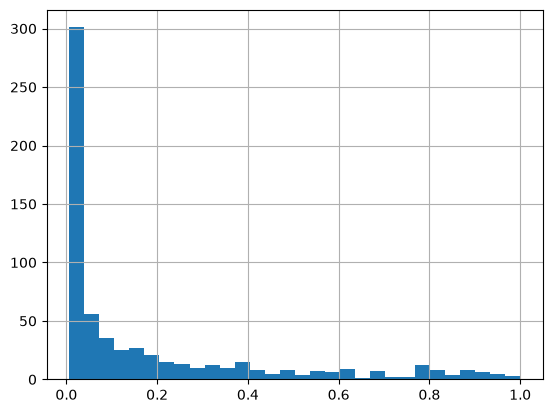

In [4]:
# Deeper EDA

# check orientation by checking which axis sums to 1 
print(f"if this is close to 100, taxa are rown -> transpose: {abundance.sum(axis=0).head().values[0]}")
print(f"if this is close to 100, taxa are column -> keep as is: {abundance.sum(axis=1).head().values[0]}")

# if needed, transpose the abundance dataframe
#abundance = abundance.T

# Sparsity check (percentage of zeros)
sparsity = (abundance == 0).sum().sum() / abundance.size
print(f"Sparsity: {sparsity:.1%}")

# prevalence per taxon (percentage of samples in which each taxon is present)
prevalence = (abundance > 0).mean(axis=0)
prevalence.sort_values(ascending=False).head(10)
prevalence.hist(bins=30)

In [5]:
# Filter low-prevalence/low-abundance taxa:

# keep taxa present in at least 10% of samples and with a mean abundance of at least 0.01%
prevalence_threshold = 0.10
abundance_threshold = 0.0001

keep_taxa = abundance.columns[
    (prevalence.values >= prevalence_threshold) &
    (abundance.mean(axis=0).values >= abundance_threshold)
]

abundance_filtered = abundance[keep_taxa]
print(f"Kept {abundance_filtered.shape[1]} of {abundance.shape[1]} taxa")


Kept 261 of 645 taxa


In [6]:
# handle zeros with a pseudocount (e.g., 1e-6) before log transformation to fix CLR (Centered Log-Ratio) issues.

def replace_zeros(row, pseudocount_ratio=0.5):
    min_nonzero = row[row > 0].min()
    pseudocount = min_nonzero * pseudocount_ratio
    row_replaced = row.replace(0, pseudocount)
    return row_replaced / row_replaced.sum() * row.sum() # normalise to original sum

abundance_nonzero = abundance_filtered.apply(replace_zeros, axis=1)

In [ ]:
# apply the CLR transformation 
from scipy.stats import gmean
def clr_transform(df):
    gm = df.apply(gmean, axis=1)
    return np.log(df.div(gm, axis=0))

abundance_clr = clr_transform(abundance_nonzero)
abundance_clr.to_csv("../data/processed/zeller2014_abundance_clr.csv")


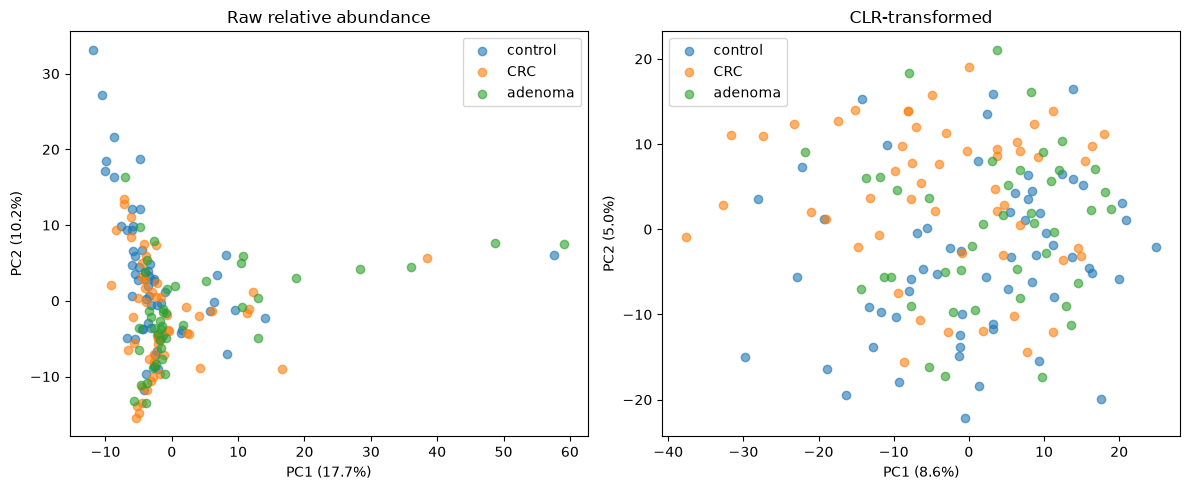

In [17]:
# Visualise before and after CLR transformation
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for data, ax, title in [(abundance_filtered, axes[0], "Raw relative abundance"),
                          (abundance_clr, axes[1], "CLR-transformed")]:
    pca = PCA(n_components=2)
    coords = pca.fit_transform(data)
    labels = metadata.loc[data.index, "study_condition"]
    for label in labels.unique():
        mask = labels == label
        ax.scatter(coords[mask, 0], coords[mask, 1], label=label, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/pca_raw_vs_clr.png", dpi=300)
plt.show()